## Decision Tree Classifier with Banknote Authentication Dataset
This is an Homework for the ELE 489: Fundamentals of Machine Learning course. This notebook implements a Decision Tree classifier on the Banknote Authentication dataset.

### İmporting Libraries
Firstly we will import the necessary libraries for our project.

In [170]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

### Loading and Reviewing the Dataset
Secondly we will load the Wine dataset and assign appropriate column names to it.

In [171]:
df = pd.read_csv("data_banknote_authentication.txt", header=None)
df.columns = ["variance", "skewness", "kurtosis", "entropy", "class"]
print(df.head())

   variance  skewness  kurtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


### Visualizing
The code below examines a pairplot of the four features in the banknote dataset. We can see that we have a clear separation between the two classes for some sets of features. For example, variance and skewness together make it easier to separate fake and real banknotes. The diagonal plots show the distribution of each feature, and we can see that they are different for each class. Also, the decision boundaries look simple, and the model gives high accuracy. Therefore, this dataset can be used for applying the decision tree algorithm easily.

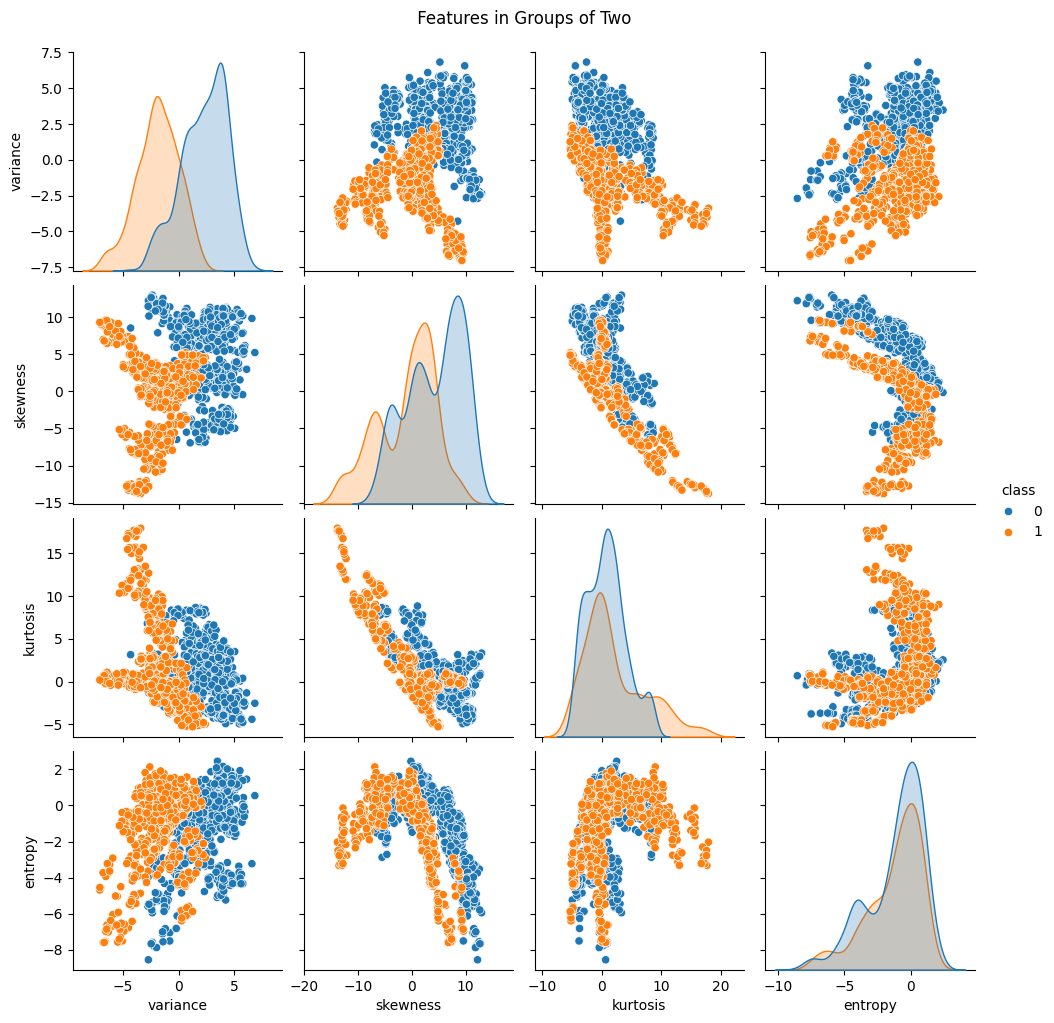

In [172]:
sns.pairplot(df, hue="class")
plt.suptitle(" Features in Groups of Two", y=1.02)
plt.show()

### Separation of Features and Target
Now we will separate the features (X) and the target variable (y).

In [173]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1] # only the last column: class
print(x.shape)
print(y.shape)

(1372, 4)
(1372,)


### Splitting Data into Training and Testing Sets
Then we will split the data into training and testing sets. Training data will be 80%, and testing data will be 20%. We used train_test_split() from sklearn to randomly split the data and set a random seed to ensure reproducibility of the split. 

In [174]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=0)

#y_train = y_train.astype(int)
#y_test = y_test.astype(int)

print(x_train.shape)
print(x_test.shape)

(1097, 4)
(275, 4)


### Implementing The Decision Tree Algorithm
The code below is to train and develop multiple decision tree models with different parameters. The criterion parameter was set either "gini" or "entropy" to observe how different splitting techniques affect the model. We also changed the max_depth value to observe how deep each tree must be, and adjusted the min_samples_split to define the minimum number of samples required to split an internal node.

In [175]:
clf_gini_4 = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=4,             
    min_samples_split=5,      
    random_state=42
)

clf_gini_4.fit(x_train, y_train)
y_pred_gi = clf_gini_4.predict(x_test)

clf_entropy_4 = DecisionTreeClassifier(
    criterion='entropy',         
    max_depth=4,             
    min_samples_split=5,      
    random_state=42
)

clf_entropy_4.fit(x_train, y_train)
y_pred_en = clf_entropy_4.predict(x_test)

clf_gini_8 = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=8,             
    min_samples_split=5,      
    random_state=42
)

clf_gini_8.fit(x_train, y_train)
y_pred_gi_8 = clf_gini_8.predict(x_test)


clf_gini_30 = DecisionTreeClassifier(
    criterion='gini',         
    max_depth=4,             
    min_samples_split=30,      
    random_state=42
)

clf_gini_30.fit(x_train, y_train)
y_pred_gi_30 = clf_gini_30.predict(x_test)

### Confusion Matrixs and Classification Reports
The confusion matrices show that both Gini and Entropy models accurately classified a majority of the samples, but the Entropy model made fewer mistakes. The Gini model misclassified 18 samples, while the Entropy model misclassified 9 samples. The Entropy model also had a slightly higher accuracy, precision, recall, and F1-score. Precisely, the Gini model attained 93.45% accuracy, while the Entropy model attained 96.73%. These statistics show that the Entropy decision tree is better suited for this dataset.

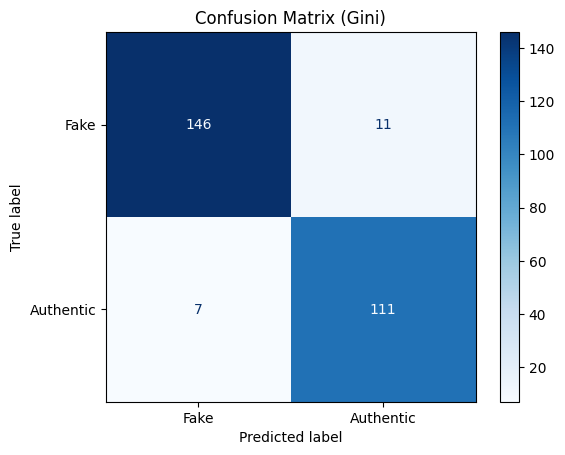

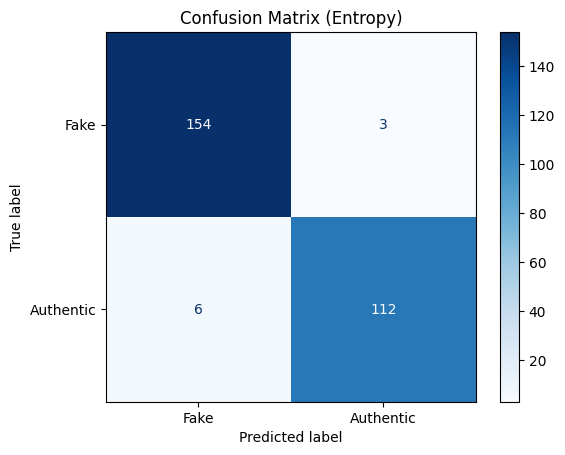

Classification Report (Gini):

              precision    recall  f1-score   support

           0     0.9542    0.9299    0.9419       157
           1     0.9098    0.9407    0.9250       118

    accuracy                         0.9345       275
   macro avg     0.9320    0.9353    0.9335       275
weighted avg     0.9352    0.9345    0.9347       275

Classification Report (Entropy):

              precision    recall  f1-score   support

           0     0.9625    0.9809    0.9716       157
           1     0.9739    0.9492    0.9614       118

    accuracy                         0.9673       275
   macro avg     0.9682    0.9650    0.9665       275
weighted avg     0.9674    0.9673    0.9672       275



In [176]:
ConfusionMatrixDisplay.from_estimator(clf_gini_4, x_test, y_test, display_labels=["Fake", "Authentic"], cmap="Blues")
plt.title("Confusion Matrix (Gini)")
ConfusionMatrixDisplay.from_estimator(clf_entropy_4, x_test, y_test, display_labels=["Fake", "Authentic"], cmap="Blues")
plt.title("Confusion Matrix (Entropy)")
plt.show()

print("Classification Report (Gini):\n")
print(classification_report(y_test, y_pred_gi, digits=4))
print("Classification Report (Entropy):\n")
print(classification_report(y_test, y_pred_en, digits=4))

### Decision Trees
The code below shows decision trees for different parameters. The Gini and Entropy trees whose both with max_depth=4 look similar, but the Entropy tree is slightly more balanced. When we increase max_depth to 8, the tree becomes much larger and harder to interpret. In contrast, setting min_samples_split=30 limits the tree growth, creating a simpler structure.

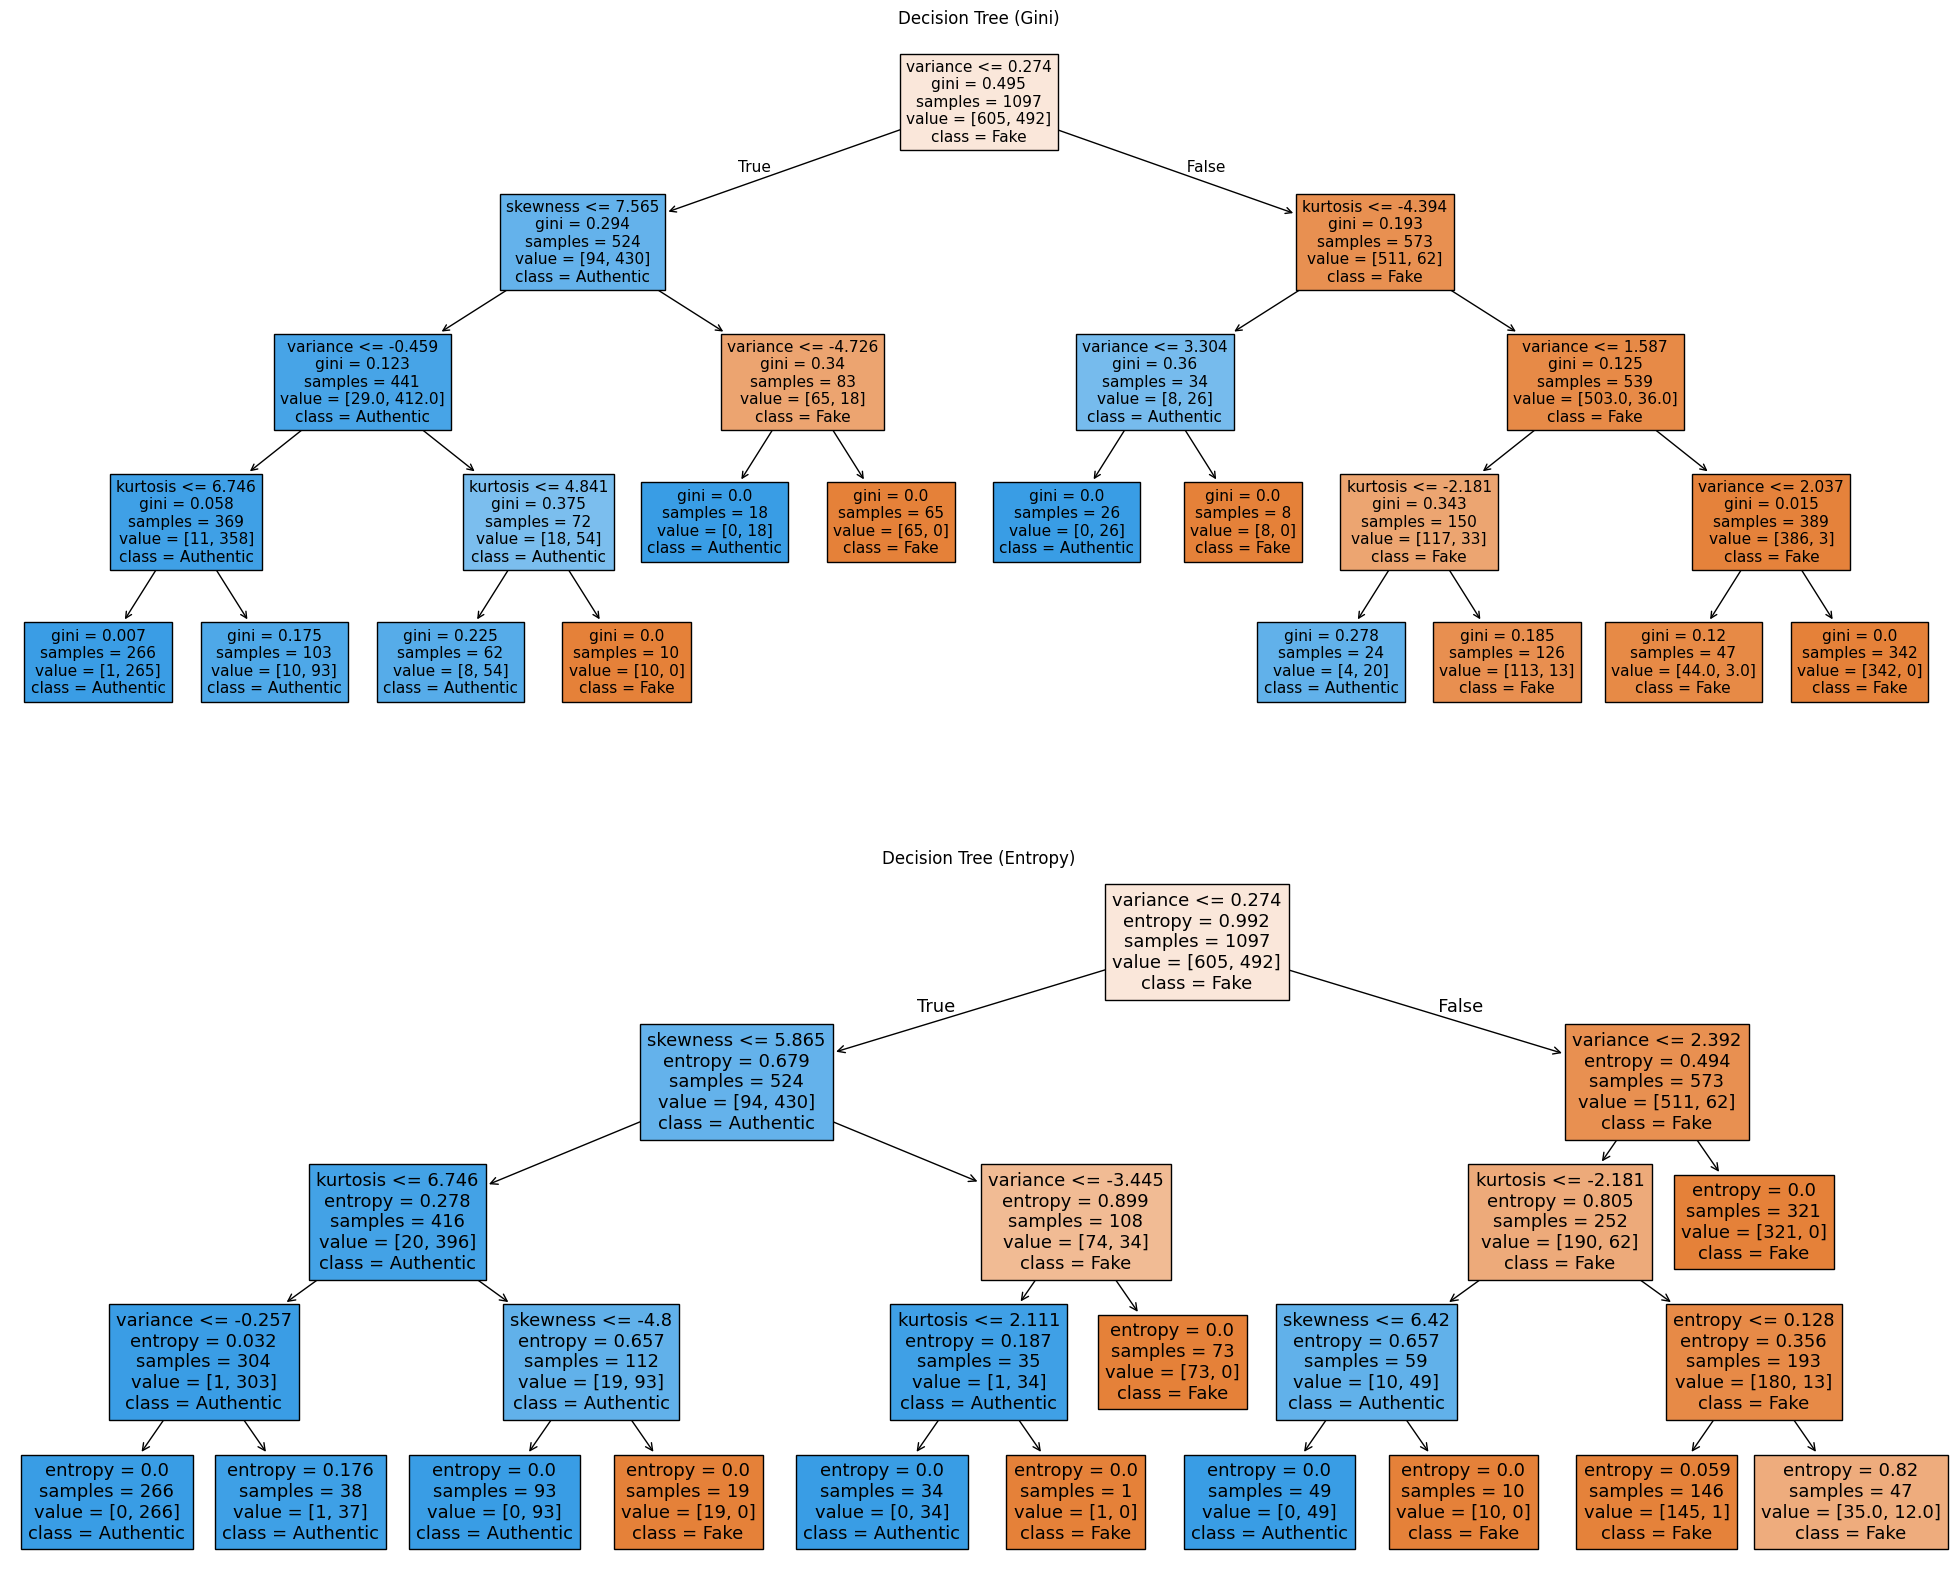

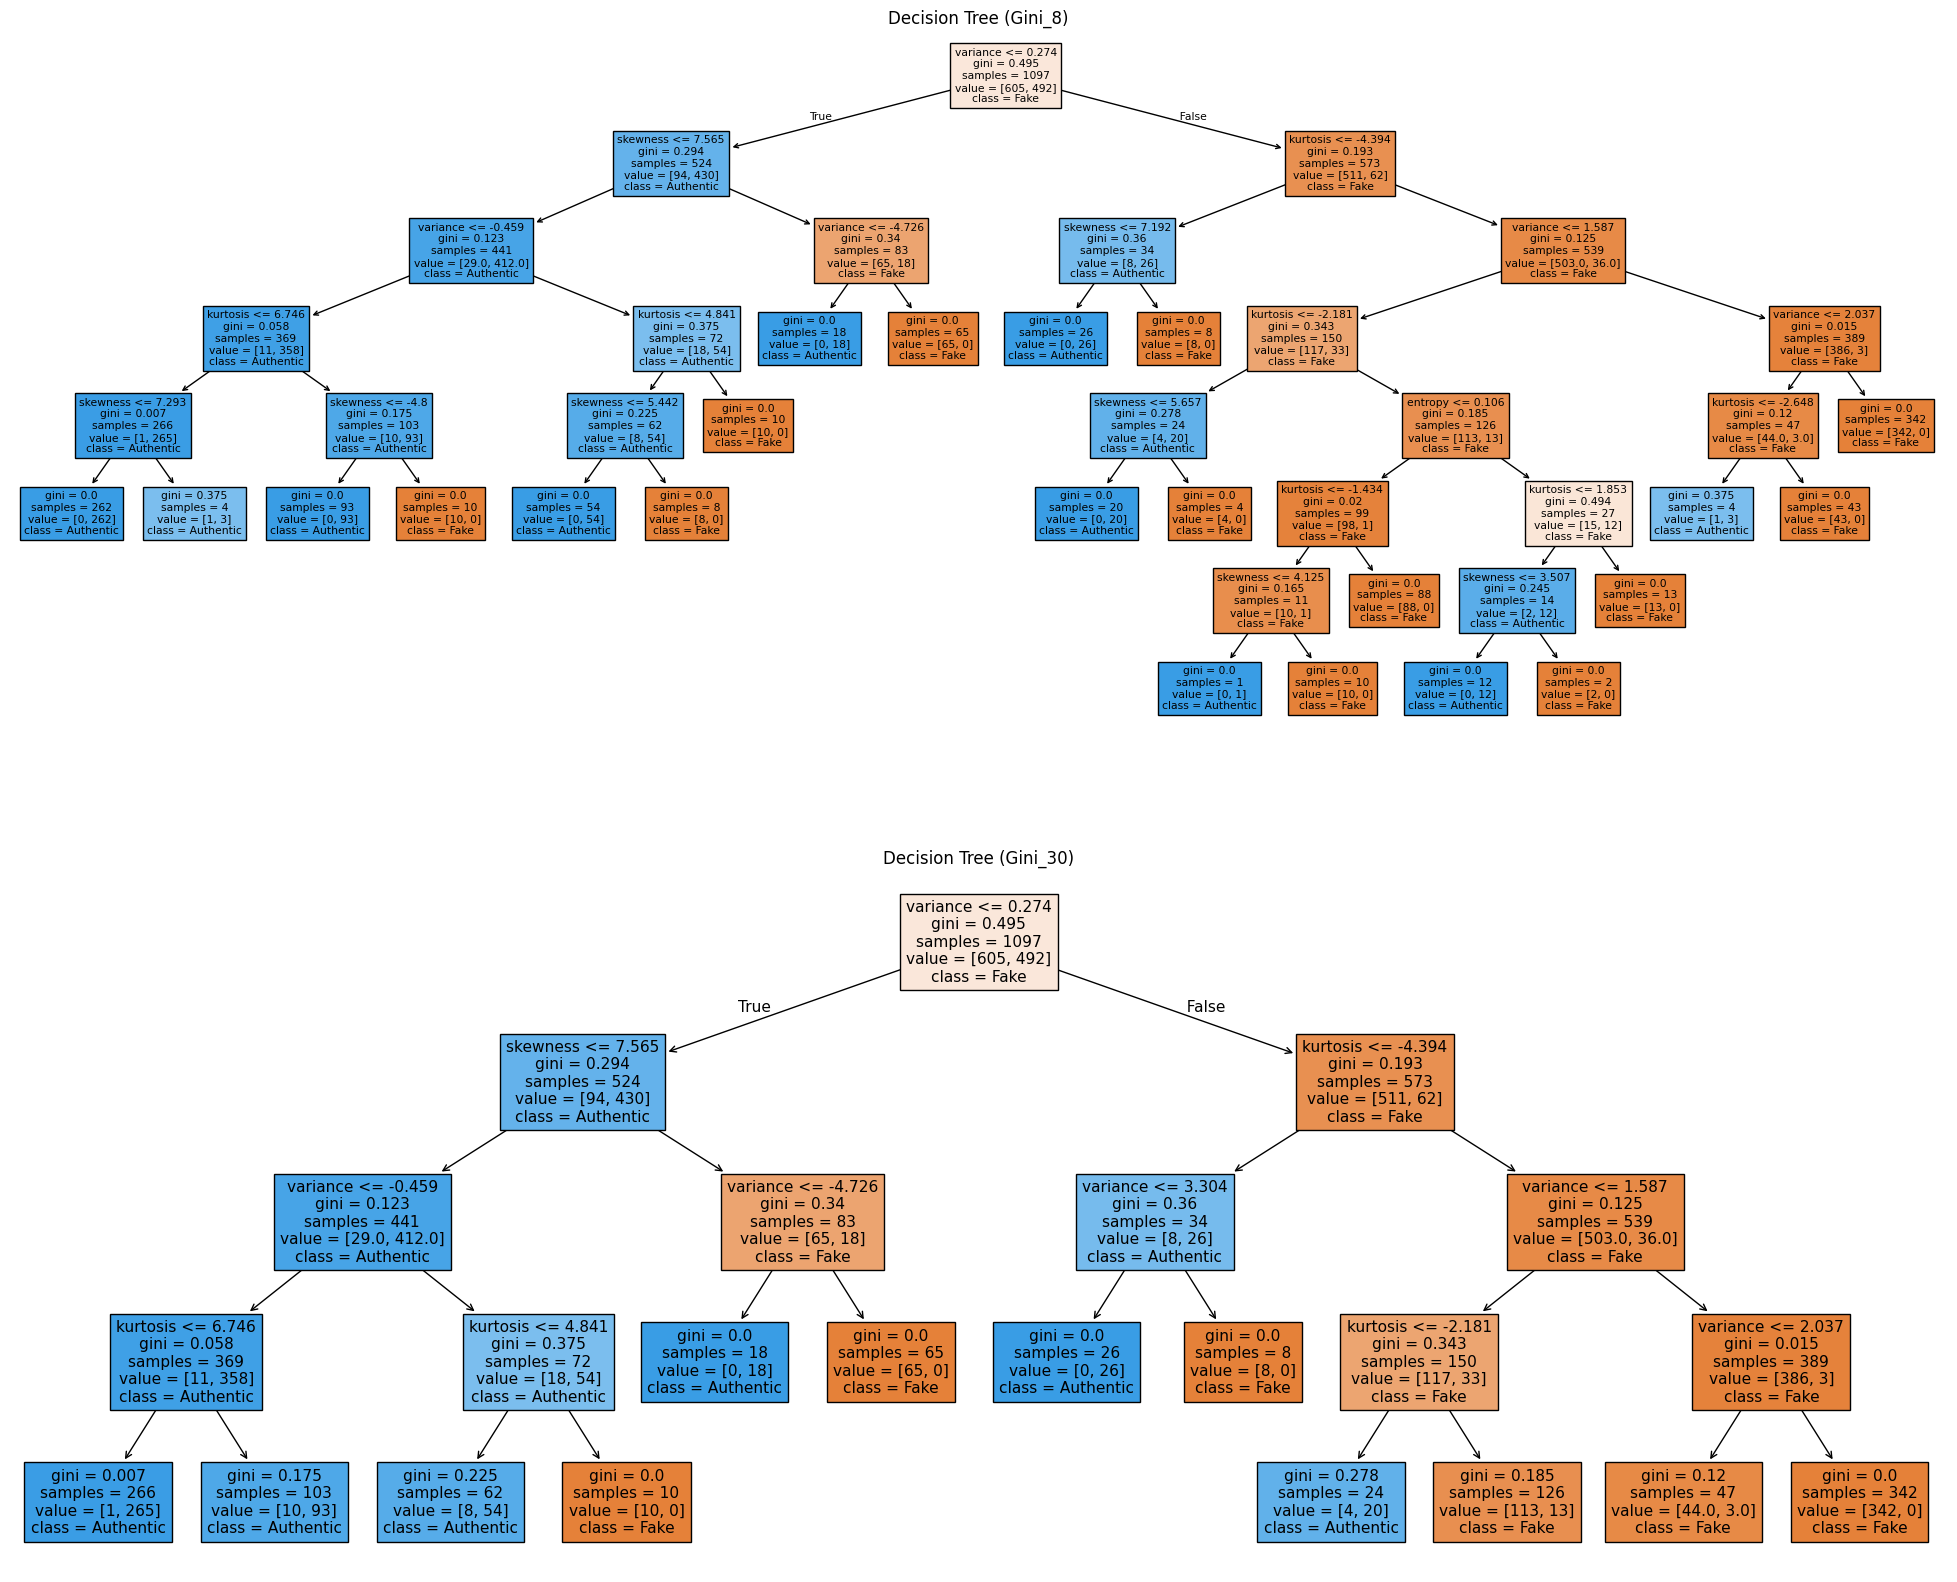

In [177]:
plt.figure(figsize=(25, 20))
plt.subplot(2,1,1)
plot_tree(clf_gini_4, feature_names=x_train.columns, class_names=["Fake", "Authentic"], filled=True)
plt.title("Decision Tree (Gini)")
plt.subplot(2,1,2)
plot_tree(clf_entropy_4, feature_names=x_train.columns, class_names=["Fake", "Authentic"], filled=True)
plt.title("Decision Tree (Entropy)")
plt.show()
plt.figure(figsize=(25, 20))
plt.subplot(2,1,1)
plot_tree(clf_gini_8, feature_names=x_train.columns, class_names=["Fake", "Authentic"], filled=True)
plt.title("Decision Tree (Gini_8)")
plt.subplot(2,1,2)
plot_tree(clf_gini_30, feature_names=x_train.columns, class_names=["Fake", "Authentic"], filled=True)
plt.title("Decision Tree (Gini_30)")
plt.show()

### Extracting Feature Importances
This code extract and sort the feature importnace for Gini and Entropy models. 

In [178]:
importances_gin = clf_gini_4.feature_importances_  
importance_df_gini = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances_gin
}).sort_values(by='Importance', ascending=False)


importances_en = clf_entropy_4.feature_importances_  
importance_df_entropy = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances_en
}).sort_values(by='Importance', ascending=False)

### Ploting the Feature Importances
The following codes plot the feature importances. These scores tell us which features were most useful in making the decisions. Higher values mean more influence on the model. In both models, variance is the most important feature However, the Entropy model gives more balanced importance to skewness and kurtosis, while the Gini model relies more heavily on variance.

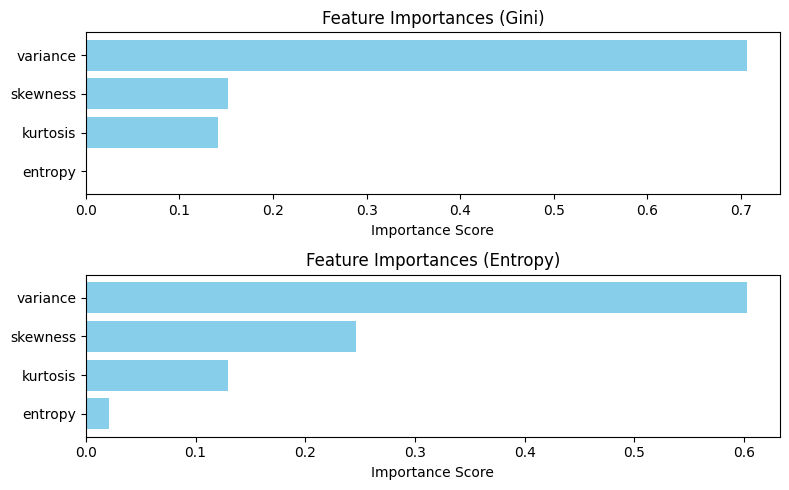

In [179]:
plt.figure(figsize=(8,5))
plt.subplot(2,1,1)
plt.barh(importance_df_gini['Feature'], importance_df_gini['Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Feature Importances (Gini)")
plt.gca().invert_yaxis()  # en önemlisi yukarıda olsun
plt.tight_layout()
plt.subplot(2,1,2)
plt.barh(importance_df_entropy['Feature'], importance_df_entropy['Importance'], color='skyblue')
plt.xlabel("Importance Score")
plt.title("Feature Importances (Entropy)")
plt.gca().invert_yaxis()  # en önemlisi yukarıda olsun
plt.tight_layout()
plt.show()